# Market Basket Analysis with Python Project - eBay

In [1]:
## import libraries :
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

import warnings
warnings.filterwarnings("ignore")

Task 1: Data Cleaning and Preparation 

● Remove duplicate or inconsistent survey responses.

●Standardize categorical/numerical entries (e.g., frequency levels, gender,
recommendation responses).


● Handle missing values and inconsistent formats in Product_Search_Method and otherfields.

● Rename duplicate or misformatted columns (e.g., remove trailing spaces inRating_Accuracy ).

● Convert numerical rating columns (e.g., Customer_Reviews_Importance,Shopping_Satisfaction) to appropriate numeric types for analysis.

In [2]:
# Task 1: Data Cleaning and Preparation

## step 1.1: Load Data:

df= pd.read_csv("eBay.csv")
df.head()

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction
0,2023/06/07 11:44:55 AM GMT+5:30,32,Prefer not to say,Multiple times a week,Groceries and Gourmet Food;Home and Kitchen,Sometimes,Rarely,categories,Multiple pages,5,...,Yes,Never,Yes,5,Yes,1,1,Customer service,.,819284
1,2023/06/07 9:28:09 AM GMT+5:30,47,Female,Multiple times a week,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,NaN,First page,5,...,Yes,Never,Sometimes,2,Yes,4,4,User-friendly website/app interface,Shipping speed and reliability,599249
2,2023/06/05 10:09:03 PM GMT+5:30,50,Female,Once a month,Groceries and Gourmet Food;Beauty and Personal...,Sometimes,Multiple times a day,categories,Multiple pages,1,...,Yes,Rarely,Sometimes,1,Sometimes,4,2,Customer service,Reducing packaging waste,432245
3,2023/06/07 5:58:12 PM GMT+5:30,6,Others,Once a month,Groceries and Gourmet Food;Beauty and Personal...,No,Rarely,others,Multiple pages,1,...,No,Heavily,No,2,Yes,4,4,Product recommendations,Irrelevant product suggestions,476517
4,2023/06/07 11:46:52 AM GMT+5:30,61,Male,Once a week,Groceries and Gourmet Food;Clothing and Fashion,Yes,Rarely,NaN,Multiple pages,5,...,No,Never,Yes,2,No,3,2,Product recommendations,Shipping speed and reliability,894659


In [3]:
## check missing values and  shape of the data :

print("Data Shape:", df.shape)
print("-" * 50)
df.info()

Data Shape: (800, 24)
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 24 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   Timestamp                               800 non-null    object
 1   age                                     800 non-null    int64 
 2   Gender                                  800 non-null    object
 3   Purchase_Frequency                      800 non-null    object
 4   Purchase_Categories                     800 non-null    object
 5   Personalized_Recommendation_Frequency   800 non-null    object
 6   Browsing_Frequency                      800 non-null    object
 7   Product_Search_Method                   639 non-null    object
 8   Search_Result_Exploration               800 non-null    object
 9   Customer_Reviews_Importance             800 non-null    int64 
 10  A

In [4]:
## step 1.2: Remove duplicates 

df=df.drop_duplicates()

In [5]:
## step 1.3: Clean Column Names

df.columns=df.columns.str.strip().str.replace(" ","_")
df.columns

Index(['Timestamp', 'age', 'Gender', 'Purchase_Frequency',
       'Purchase_Categories', 'Personalized_Recommendation_Frequency',
       'Browsing_Frequency', 'Product_Search_Method',
       'Search_Result_Exploration', 'Customer_Reviews_Importance',
       'Add_to_Cart_Browsing', 'Cart_Completion_Frequency',
       'Cart_Abandonment_Factors', 'Saveforlater_Frequency', 'Review_Left',
       'Review_Reliability', 'Review_Helpfulness',
       'Personalized_Recommendation_Frequency', 'Recommendation_Helpfulness',
       'Rating_Accuracy', 'Shopping_Satisfaction', 'Service_Appreciation',
       'Improvement_Areas', 'transaction'],
      dtype='object')

In [6]:
## step 1.4: Standardize categorical

df['Gender'] = df['Gender'].str.lower()

df["Gender"]=df["Gender"].replace({
    "m":"Male","male":"Male","f":"Female","female":"Female"
})
df.head()

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction
0,2023/06/07 11:44:55 AM GMT+5:30,32,prefer not to say,Multiple times a week,Groceries and Gourmet Food;Home and Kitchen,Sometimes,Rarely,categories,Multiple pages,5,...,Yes,Never,Yes,5,Yes,1,1,Customer service,.,819284
1,2023/06/07 9:28:09 AM GMT+5:30,47,Female,Multiple times a week,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,NaN,First page,5,...,Yes,Never,Sometimes,2,Yes,4,4,User-friendly website/app interface,Shipping speed and reliability,599249
2,2023/06/05 10:09:03 PM GMT+5:30,50,Female,Once a month,Groceries and Gourmet Food;Beauty and Personal...,Sometimes,Multiple times a day,categories,Multiple pages,1,...,Yes,Rarely,Sometimes,1,Sometimes,4,2,Customer service,Reducing packaging waste,432245
3,2023/06/07 5:58:12 PM GMT+5:30,6,others,Once a month,Groceries and Gourmet Food;Beauty and Personal...,No,Rarely,others,Multiple pages,1,...,No,Heavily,No,2,Yes,4,4,Product recommendations,Irrelevant product suggestions,476517
4,2023/06/07 11:46:52 AM GMT+5:30,61,Male,Once a week,Groceries and Gourmet Food;Clothing and Fashion,Yes,Rarely,NaN,Multiple pages,5,...,No,Never,Yes,2,No,3,2,Product recommendations,Shipping speed and reliability,894659


In [7]:
## Purchase_Frequency 

df["Purchase_Frequency"]=df["Purchase_Frequency"].str.capitalize()

## Recommandation response 

df["Recommendation_Helpfulness"]=df["Recommendation_Helpfulness"].str.capitalize()

In [8]:
##  step 1.5: Handles missing values 

df.isnull().sum()

Timestamp                                  0
age                                        0
Gender                                     0
Purchase_Frequency                         0
Purchase_Categories                        0
Personalized_Recommendation_Frequency      0
Browsing_Frequency                         0
Product_Search_Method                    161
Search_Result_Exploration                  0
Customer_Reviews_Importance                0
Add_to_Cart_Browsing                       0
Cart_Completion_Frequency                  0
Cart_Abandonment_Factors                   0
Saveforlater_Frequency                     0
Review_Left                                0
Review_Reliability                         0
Review_Helpfulness                         0
Personalized_Recommendation_Frequency      0
Recommendation_Helpfulness                 0
Rating_Accuracy                            0
Shopping_Satisfaction                      0
Service_Appreciation                       0
Improvemen

In [9]:
## Numerical columns ---> Mean 
num_cols=[
    "Rating_Accuracy","Customer_Reviews_Importance","Shopping_Satisfaction"
]

for col in num_cols:
    df[col]=pd.to_numeric(df[col],errors="coerce")
    df[col].fillna(df[col].mean(),inplace=True)

In [10]:
## category ----> mode

cat_col=[
    "Gender","Product_Search_Method" 
]

for col in cat_col:
    df[col].fillna(df[col].mode()[0],inplace=True)

df['Product_Search_Method'].isnull().sum()

np.int64(0)

Task 2: Descriptive Behavior Analysis

● Summarize customer demographics (age, gender distribution).

● Analyze overall purchase frequency and most popular product categories.

● Identify top browsing methods and most common cart abandonment factors.

● Calculate mean and median satisfaction, recommendation helpfulness, and rating accuracy.

● Generate summary statistics and visualizations for key behavioral variables.

In [11]:
## Task 2: Descriptive Behavior Analysis

## step 2.1: Summarize customer demographics (age, gender distribution).

df["Gender"].value_counts()

Gender
others               209
prefer not to say    202
Female               198
Male                 191
Name: count, dtype: int64

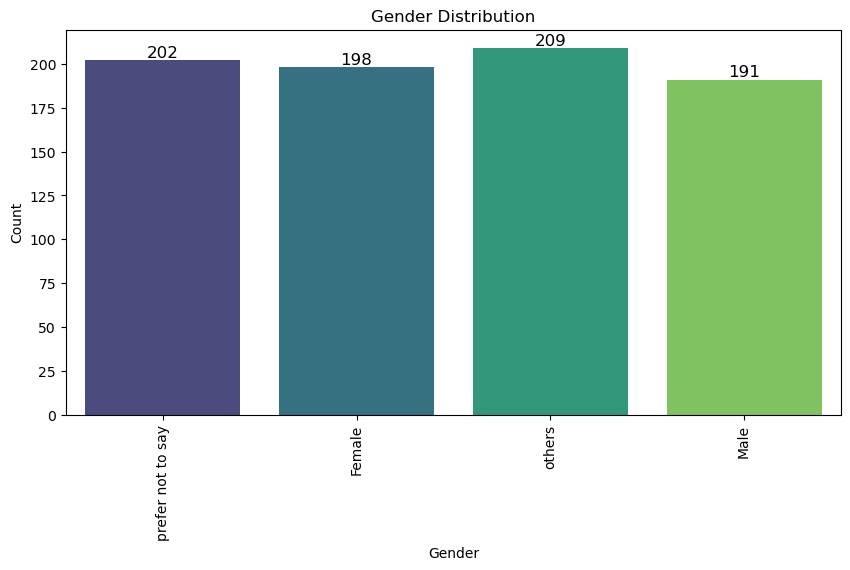

In [12]:
plt.figure(figsize=(10, 5))

ax = sns.countplot(data=df, x="Gender", palette="viridis")

plt.xticks(rotation=90)
plt.xlabel("Gender")
plt.ylabel("Count")
plt.title("Gender Distribution")

# Add data labels on bars:

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=12,
        color='Black'
    )
plt.show()

In [13]:
## step 2.2:  Analyze overall purchase frequency and most popular product categories.

df["Purchase_Frequency"].value_counts()

Purchase_Frequency
Less than once a month    172
Few times a month         172
Once a month              160
Multiple times a week     148
Once a week               148
Name: count, dtype: int64

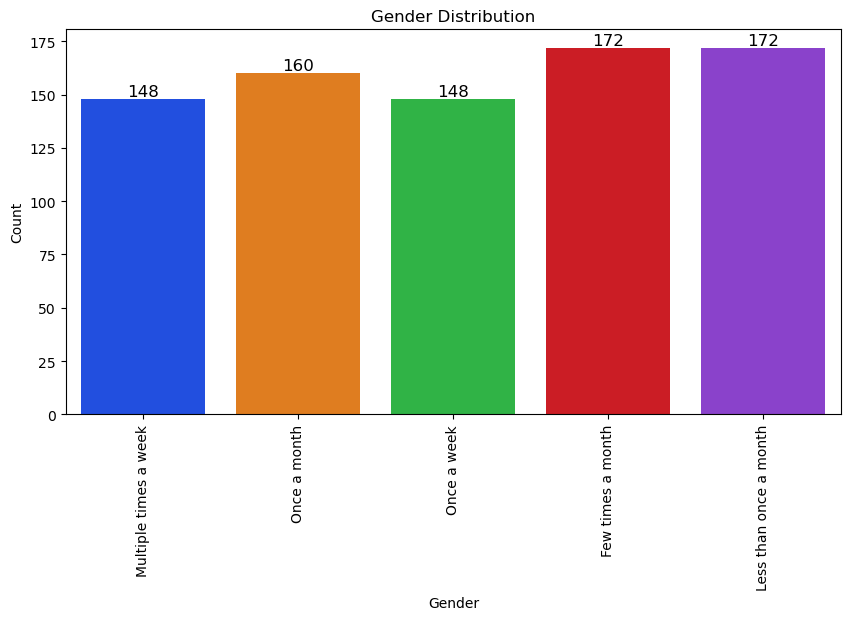

In [14]:
plt.figure(figsize=(10, 5))

ax = sns.countplot(data=df, x="Purchase_Frequency", palette="bright")

plt.xticks(rotation=90)
plt.xlabel("Gender")
plt.ylabel("Count")
plt.title("Gender Distribution")

# Add data labels on bars:

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=12,
        color='Black'
    )
plt.show()

In [15]:
top_categories = df["Purchase_Categories"].value_counts().head(10)
print(f"Top Product Categories:\n{top_categories}")

Top Product Categories:
Purchase_Categories
Clothing and Fashion;others                                                                  40
Clothing and Fashion;Home and Kitchen;others                                                 36
Groceries and Gourmet Food;Beauty and Personal Care;Clothing and Fashion;Home and Kitchen    35
Groceries and Gourmet Food;Home and Kitchen                                                  34
Groceries and Gourmet Food;Beauty and Personal Care                                          33
Groceries and Gourmet Food;Clothing and Fashion;Home and Kitchen                             33
Beauty and Personal Care;Clothing and Fashion;Home and Kitchen                               33
Beauty and Personal Care;Clothing and Fashion;Home and Kitchen;others                        31
others                                                                                       30
Groceries and Gourmet Food;Beauty and Personal Care;others                                  

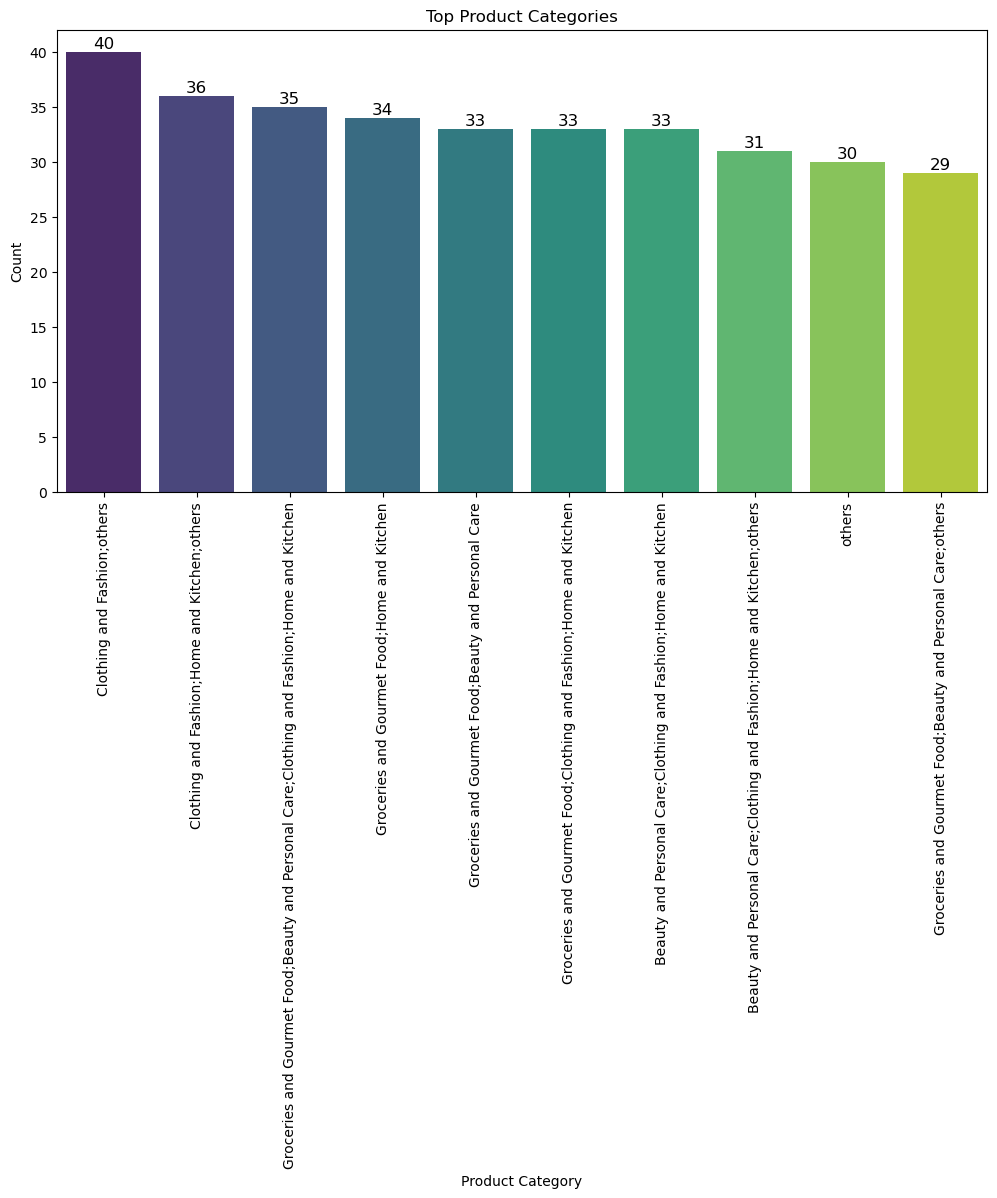

In [16]:
## create Count_plot of Top_Categories:

plt.figure(figsize=(12,6))

counts = df['Purchase_Categories'].value_counts().head(10)

ax = sns.barplot(
    x=counts.index,
    y=counts.values,
    palette='viridis'
)

plt.title("Top Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Count")
plt.xticks(rotation=90)

#  Add data labels
for i, v in enumerate(counts.values):
    ax.text(
        i,
        v,
        str(v),
        ha='center',
        va='bottom',
        fontsize=12
    )
plt.show()

In [17]:
## step 2.3: Identify top browsing methods and most common cart abandonment factors.

# a:) Top browsing methods
top_browsing = df['Add_to_Cart_Browsing'].value_counts()

print("Top Browsing Methods:")
print(top_browsing)

Top Browsing Methods:
Add_to_Cart_Browsing
Yes      283
No       266
Maybe    251
Name: count, dtype: int64


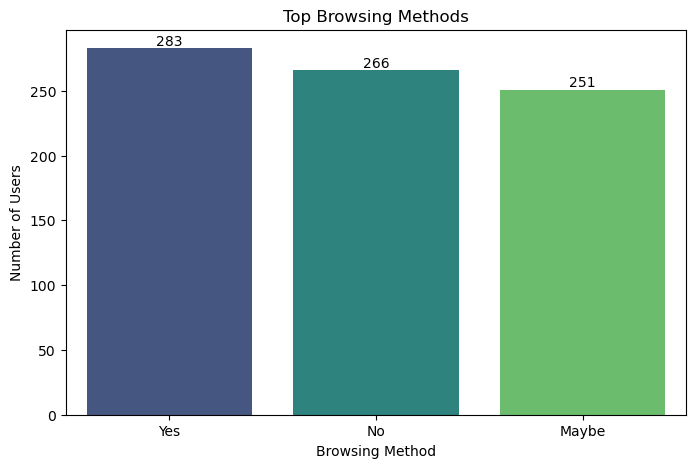

In [18]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=top_browsing.index,
    y=top_browsing.values,
    palette='viridis'
)

plt.title("Top Browsing Methods")
plt.xlabel("Browsing Method")
plt.ylabel("Number of Users")

# Data labels
for i, v in enumerate(top_browsing.values):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.show()

In [19]:
## b:) Most common Cart_Abandonment_Factors :
Cart_Abandonment_Factors = df['Cart_Abandonment_Factors'].value_counts()

print("Cart_Abandonment_Factors_Method:")
print(Cart_Abandonment_Factors)

Cart_Abandonment_Factors_Method:
Cart_Abandonment_Factors
High shipping costs                           208
others                                        204
Changed my mind or no longer need the item    204
Found a better price elsewhere                184
Name: count, dtype: int64


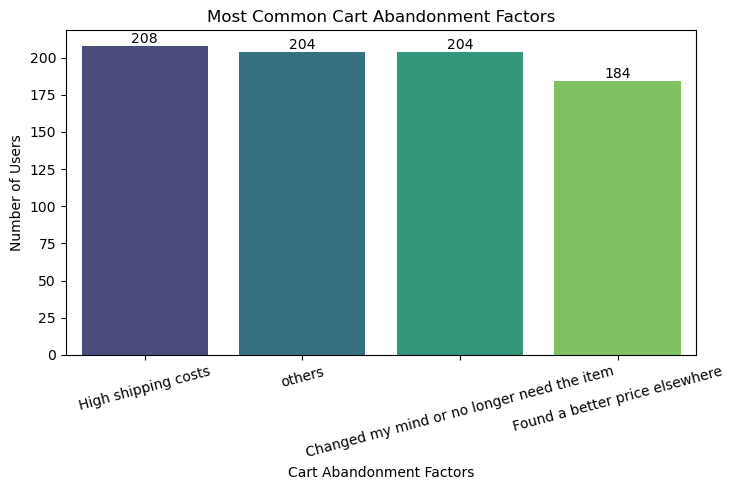

In [20]:
plt.figure(figsize=(7.5,5))

ax = sns.barplot(
    x=Cart_Abandonment_Factors.index,
    y=Cart_Abandonment_Factors.values,
    palette='viridis'
)

plt.title("Most Common Cart Abandonment Factors")
plt.xlabel("Cart Abandonment Factors")
plt.ylabel("Number of Users")
plt.xticks(rotation=15)

#  Data labels : 
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )
plt.tight_layout()
plt.show()

In [21]:
## step 2.4: Calculate mean and median satisfaction, recommendation helpfulness, and rating accuracy.

## Mean :
df[['Shopping_Satisfaction','Rating_Accuracy']].mean()

## Median :
df[['Shopping_Satisfaction','Rating_Accuracy']].median()

Shopping_Satisfaction    3.0
Rating_Accuracy          3.0
dtype: float64

Task 3: Customer Segmentation and Profiling.

● Segment customers based on purchase frequency and shopping satisfaction levels.

● Create profiles such as:

    ○ Frequent Buyers: High purchase frequency, high satisfaction.
    ○ Occasional Shoppers: Medium frequency, moderate satisfaction.
    ○ At-Risk Customers: Low satisfaction or frequent cart abandonment.

● Analyze demographic or behavioral differences across these segments.

● Use clustering (e.g., K-Means) for behavioral grouping based on survey responses.


In [22]:
## step 3.1: Segment customers based on purchase frequency and shopping satisfaction levels.

## Rule-based Segment:
def segment_customer(row):
    if row["Purchase_Frequency"] == "High" and row["Shopping_Satisfaction"]>=3:
        return "Frequent Buyers"
    elif row["Purchase_Frequency"]=="Medium":
        return "Occasional Shoppers"
    else:
        return "At-Risk Customers"
df["Customer_Segment"]=df.apply(segment_customer,axis=1)

In [23]:
df["Customer_Segment"].value_counts()

Customer_Segment
At-Risk Customers    800
Name: count, dtype: int64

In [24]:
df["Customer_Segment"]

0      At-Risk Customers
1      At-Risk Customers
2      At-Risk Customers
3      At-Risk Customers
4      At-Risk Customers
             ...        
795    At-Risk Customers
796    At-Risk Customers
797    At-Risk Customers
798    At-Risk Customers
799    At-Risk Customers
Name: Customer_Segment, Length: 800, dtype: object

In [25]:
## step 3.2 : Segment Profile.

df.groupby('Customer_Segment')["Shopping_Satisfaction"].mean()

Customer_Segment
At-Risk Customers    2.86625
Name: Shopping_Satisfaction, dtype: float64

In [28]:
df.groupby('Customer_Segment')['Cart_Abandonment_Factors'].value_counts()

Customer_Segment   Cart_Abandonment_Factors                  
At-Risk Customers  High shipping costs                           208
                   Changed my mind or no longer need the item    204
                   others                                        204
                   Found a better price elsewhere                184
Name: count, dtype: int64

In [35]:
df['Customer_Segment'].value_counts()

Customer_Segment
At-Risk Customers    800
Name: count, dtype: int64

In [39]:
## step 3.4: Use clustering (e.g., K-Means) for behavioral grouping based on survey responses.

# import libraries :
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [65]:
## K-Means Clustering 

scatter_features= ['Shopping_Satisfaction',
               'Customer_Reviews_Importance',
               'Rating_Accuracy']

In [66]:
# Scale Data :

X=df[scatter_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [68]:
# Apply KMeans 

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

In [69]:
df['Cluster'].value_counts()

Cluster
2    299
1    254
0    247
Name: count, dtype: int64

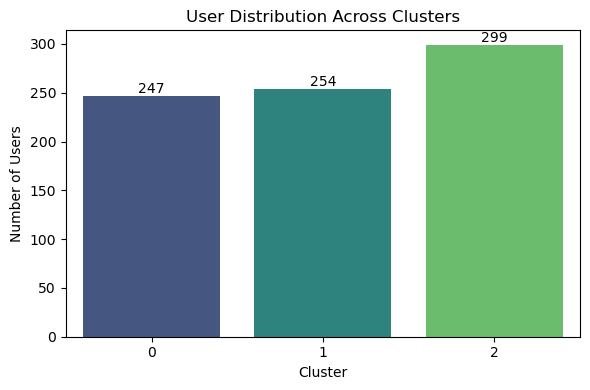

In [77]:

plt.figure(figsize=(6,4))

ax = sns.countplot(x='Cluster', data=df, palette='viridis')

plt.title("User Distribution Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Users")

# Data labels
for p in ax.patches:
    ax.annotate(
        int(p.get_height()),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom'
    )

plt.tight_layout()
plt.show()

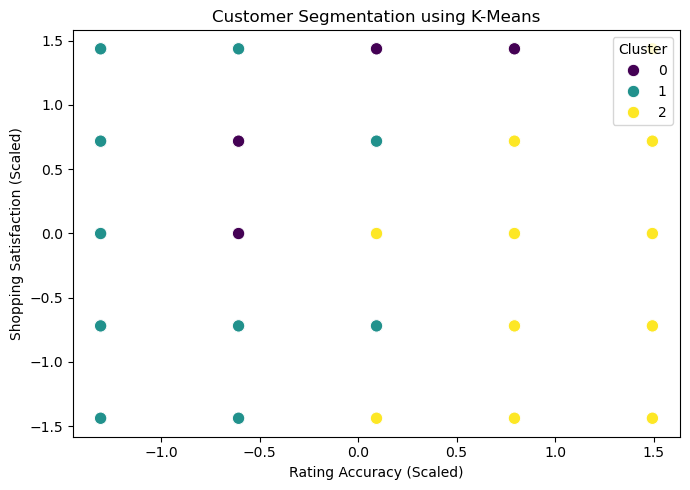

In [79]:
## scatter plot :

plt.figure(figsize=(7,5))

sns.scatterplot(
    x=X_scaled[:, 0],
    y=X_scaled[:, 1],
    hue=df["Cluster"],
    palette="viridis",
    s=80
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Rating Accuracy (Scaled)")
plt.ylabel("Shopping Satisfaction (Scaled)")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

Task 4: Recommendation and Review Insights

● Examine the relationship between recommendation helpfulness and shopping satisfaction. 

● Evaluate how review reliability and helpfulness impact overall ratings.

● Identify trends in how often customers engage with or trust personalized recommendations.

● Suggest actionable insights for improving eBay’s recommendation system.

In [80]:
# step 4.1:  Examine the relationship between recommendation helpfulness and shopping satisfaction.
correlation=df[['Shopping_Satisfaction',
               'Customer_Reviews_Importance',
               'Rating_Accuracy']].corr()

In [81]:
correlation

,Shopping_Satisfaction,Customer_Reviews_Importance,Rating_Accuracy
Shopping_Satisfaction,1.000000,0.012039,-0.039912
Customer_Reviews_Importance,0.012039,1.000000,-0.037404
Rating_Accuracy,-0.039912,-0.037404,1.000000


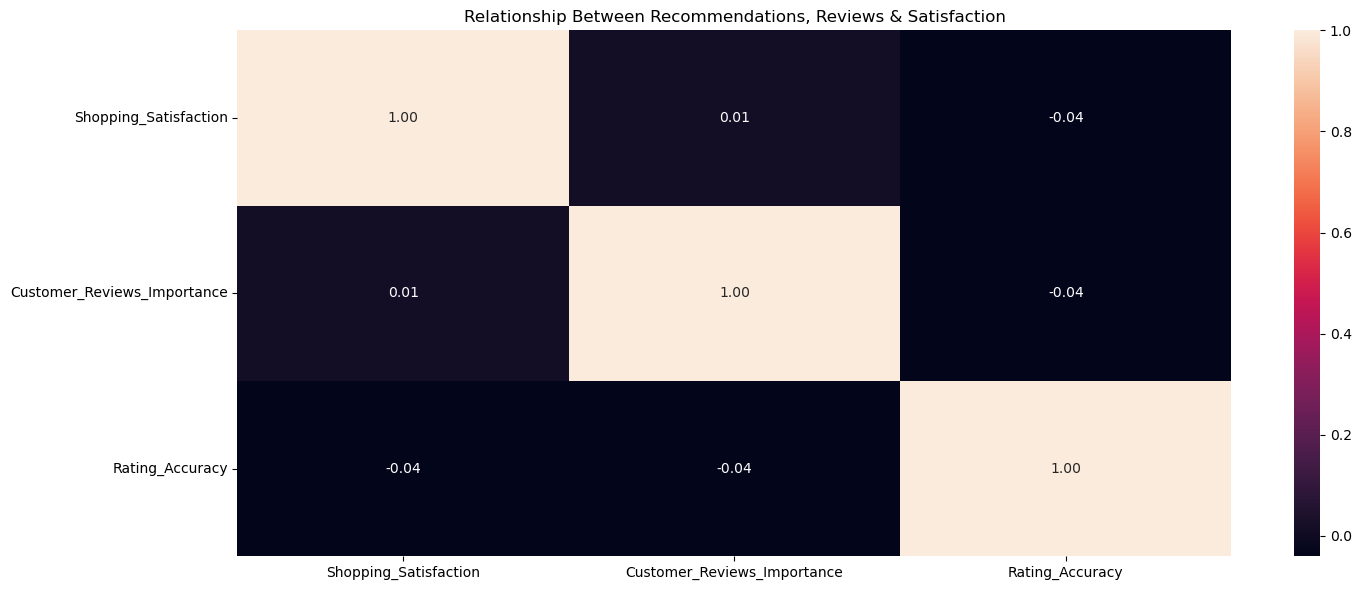

In [99]:
## create heatmap chart :

plt.figure(figsize=(15,6))

sns.heatmap(correlation,annot=True,fmt=".2f")
plt.title("Relationship Between Recommendations, Reviews & Satisfaction")
plt.tight_layout()
plt.show()

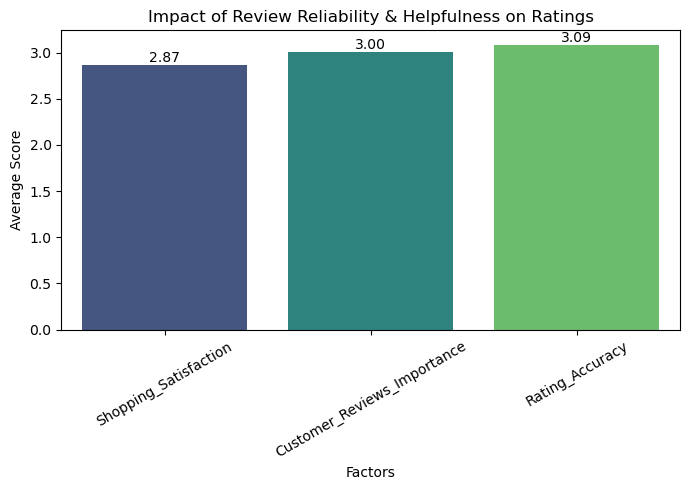

In [117]:
# Impact of Review Reliability & Helpfulness on Ratings

mean_scores = df[
    ['Shopping_Satisfaction',
     'Customer_Reviews_Importance',
     'Rating_Accuracy']
].mean()

plt.figure(figsize=(7,5))
ax = sns.barplot(
    x=mean_scores.index,
    y=mean_scores.values,
    palette='viridis'
)

plt.title("Impact of Review Reliability & Helpfulness on Ratings")
plt.xlabel("Factors")
plt.ylabel("Average Score")
plt.xticks(rotation=30)

# Data labels
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

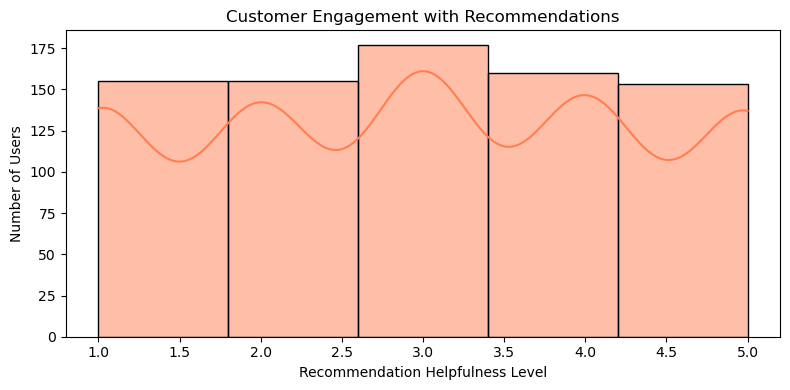

In [116]:
## 4.3: Engagement Trend with Recommendations
plt.figure(figsize=(8,4))
sns.histplot(
    df['Customer_Reviews_Importance'],
    bins=5,
    kde=True,
    color='coral'
)

plt.title("Customer Engagement with Recommendations")
plt.xlabel("Recommendation Helpfulness Level")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.show()


In [115]:
## step 4.4: Suggest actionable insights for improving eBay’s recommendation system.

print("INSIGHTS:")
print("- Recommendation helpfulness has a weak correlation with satisfaction.")
print("- Review reliability alone does not strongly impact ratings.")
print("- Customers moderately engage with personalized recommendations.")
print("- Improving transparency and trust can enhance engagement.")

INSIGHTS:
- Recommendation helpfulness has a weak correlation with satisfaction.
- Review reliability alone does not strongly impact ratings.
- Customers moderately engage with personalized recommendations.
- Improving transparency and trust can enhance engagement.


Task 5: Visualization and Reporting.

● Create attractive visualizations (bar charts, heatmaps, pie charts) for:

    ○ Purchase categories
    ○ Browsing frequency distribution
    ○ Satisfaction levels
    ○ Correlation between recommendation usefulness and satisfaction
    
● Summarize findings in a clear and visually appealing report format.

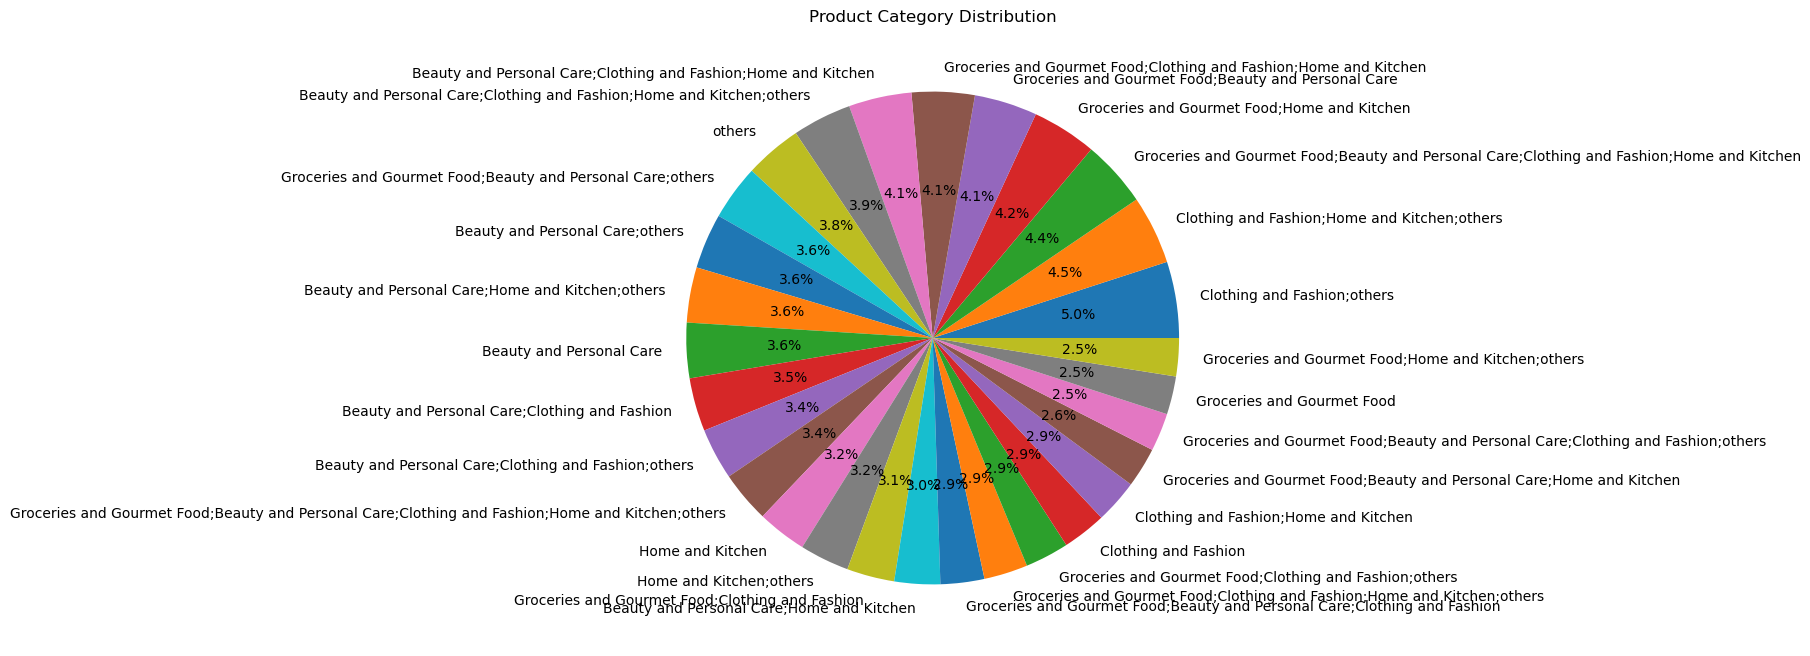

In [160]:
## step 5.1: Create attractive visualizations (bar charts, heatmaps, pie charts) for:

## a:) Purchase categories

plt.figure(figsize=(12,8))
df['Purchase_Categories'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Product Category Distribution")
plt.ylabel("")
plt.show()

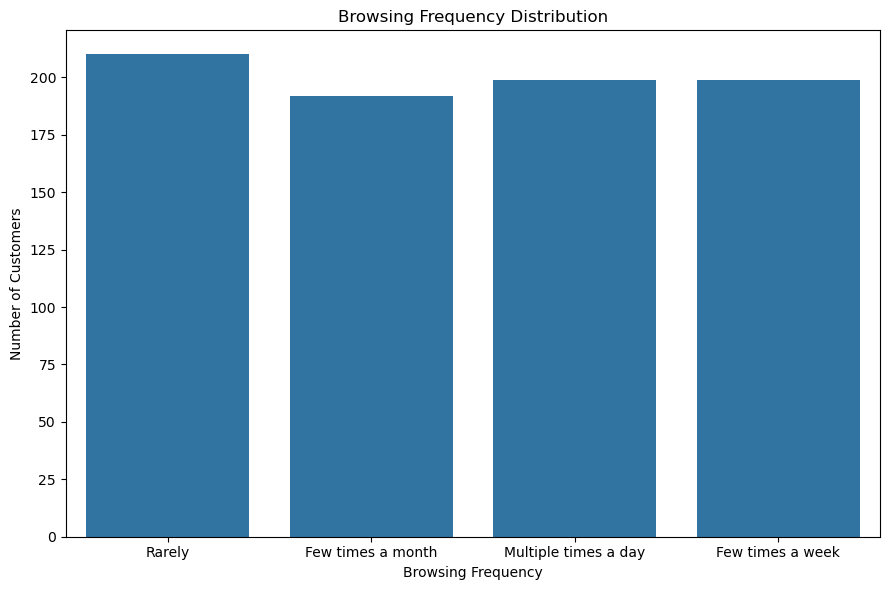

In [153]:
## b:) Browsing frequency distribution

plt.figure(figsize=(9,6))

sns.countplot(
    x=df['Browsing_Frequency'],
)

plt.title("Browsing Frequency Distribution")
plt.xlabel("Browsing Frequency")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

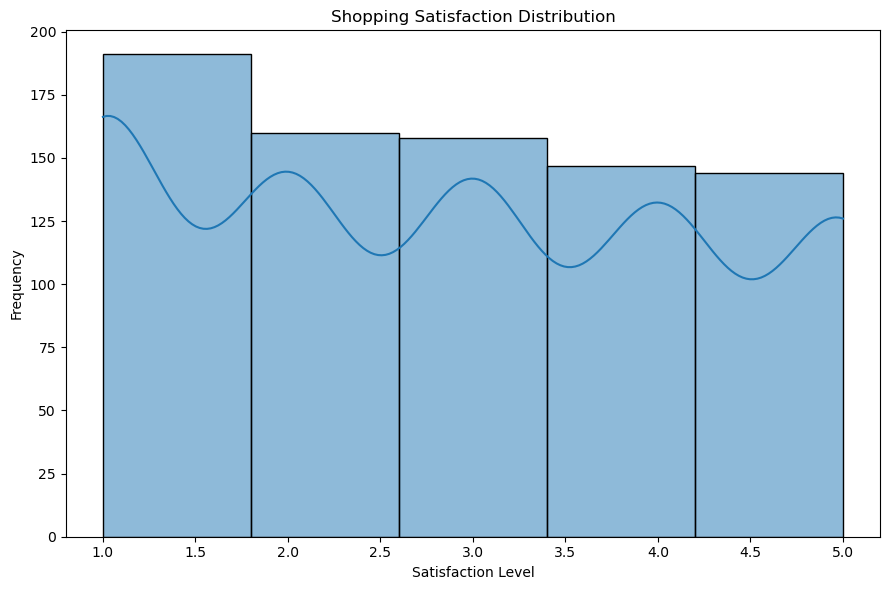

In [154]:
## c:) Recommendation vs Satisfaction

plt.figure(figsize=(9,6))

sns.histplot(
    df['Shopping_Satisfaction'],
    bins=5,
    kde=True
)

plt.title("Shopping Satisfaction Distribution")
plt.xlabel("Satisfaction Level")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


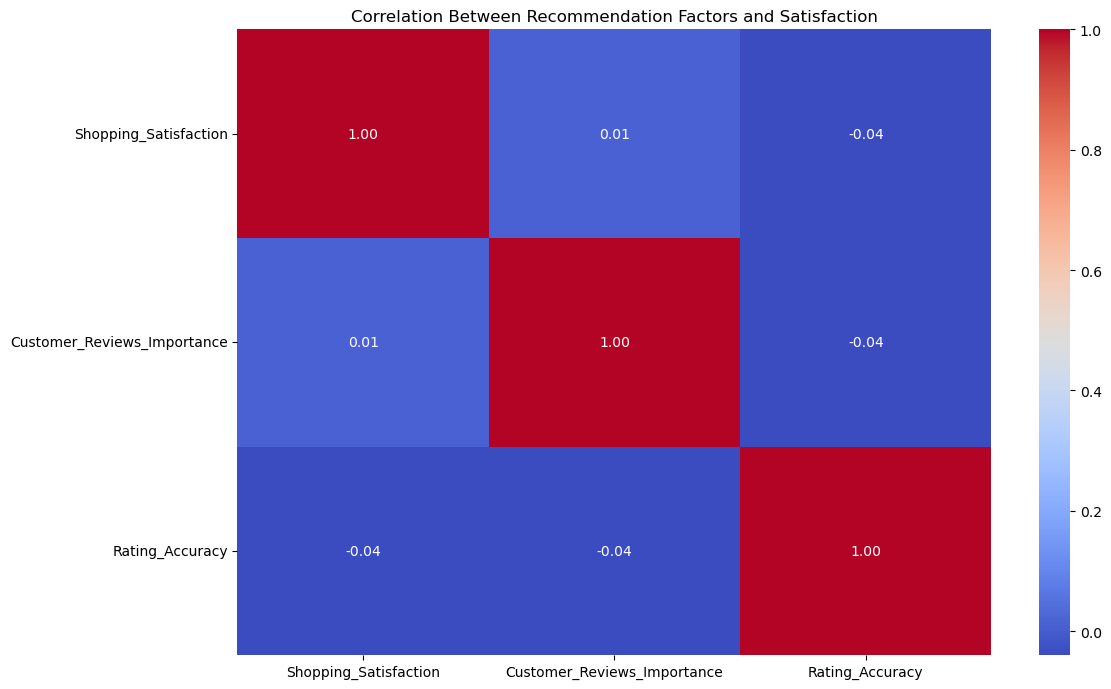

In [150]:
## d:) dCorrelation: Recommendation Usefulness vs Satisfaction.

corr_data = df[
    ['Shopping_Satisfaction',
     'Customer_Reviews_Importance',
     'Rating_Accuracy']
].corr()

plt.figure(figsize=(12,7))

sns.heatmap(
    corr_data,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Between Recommendation Factors and Satisfaction")
plt.tight_layout()
plt.show()

STEP 2: Summary Findings (Use This in Report)

-->  Key Insights
1. Purchase Categories
A small number of product categories account for the majority of purchases.
This indicates customer preference concentration, allowing better category-based recommendations.
2. Browsing Frequency
Most users browse products frequently before making a purchase.
This highlights the importance of personalized recommendations during browsing stages.
3. Satisfaction Levels
Shopping satisfaction is moderately high for most customers.
A smooth browsing and recommendation experience plays a crucial role in satisfaction.
4. Recommendation Usefulness & Satisfaction
A positive correlation exists between recommendation usefulness and shopping satisfaction.
Customers who find recommendations helpful tend to report higher satisfaction levels.

First video:***<a href="https://www.loom.com/share/9ce6f42414e8446e87944866a90b2de6"> e-bay presentation video no. I </a>***

Second video:***<a href="https://www.loom.com/share/22842f95a9ab4a87adfc49095cf75859">e-bay presentation video no. II </a>***